# Web Scraping

import requests
a = requests.get("https://books.toscrape.com/")

In [118]:
for i in range(1,51):
    a = requests.get(f"https://books.toscrape.com/catalogue/page-{i}.html")
    with open(f"HTMLS/page{i}.html", "w" , encoding="utf-8") as f:
        f.write(a.text)
        print(f"Downloaded page {i} successfully")

Downloaded page 1 successfully
Downloaded page 2 successfully
Downloaded page 3 successfully
Downloaded page 4 successfully
Downloaded page 5 successfully
Downloaded page 6 successfully
Downloaded page 7 successfully
Downloaded page 8 successfully
Downloaded page 9 successfully
Downloaded page 10 successfully
Downloaded page 11 successfully
Downloaded page 12 successfully
Downloaded page 13 successfully
Downloaded page 14 successfully
Downloaded page 15 successfully
Downloaded page 16 successfully
Downloaded page 17 successfully
Downloaded page 18 successfully
Downloaded page 19 successfully
Downloaded page 20 successfully
Downloaded page 21 successfully
Downloaded page 22 successfully
Downloaded page 23 successfully
Downloaded page 24 successfully
Downloaded page 25 successfully
Downloaded page 26 successfully
Downloaded page 27 successfully
Downloaded page 28 successfully
Downloaded page 29 successfully
Downloaded page 30 successfully
Downloaded page 31 successfully
Downloaded page 3

In [ ]:
# Parsed HTML using BeautifulSoup

In [10]:
from bs4 import BeautifulSoup
import pandas as pd

In [11]:
with open("HTMLS/page1.html","r", encoding="utf-8") as f:
    content=f.read()
soup = BeautifulSoup(content, "html.parser")

In [18]:
articles=soup.find_all("article",class_="product_pod")
print(len(articles))

20


In [19]:
items = []
for article in articles:
    title = article.find("h3").find("a")["title"]
    price=article.find("p",class_="price_color").text.split("£")[1]
    rating_element = article.select_one("p.star-rating")
    rating = rating_element['class'][1]
    stock=article.find("p",class_="instock availability").text.strip()
    items.append([title,price,rating,stock])

In [20]:
items

[['Frankenstein', '38.00', 'Two', 'In stock'],
 ['Forever Rockers (The Rocker #12)', '28.80', 'Three', 'In stock'],
 ['Fighting Fate (Fighting #6)', '39.24', 'Three', 'In stock'],
 ['Emma', '32.93', 'Two', 'In stock'],
 ['Eat, Pray, Love', '51.32', 'Three', 'In stock'],
 ['Deep Under (Walker Security #1)', '47.09', 'Five', 'In stock'],
 ["Choosing Our Religion: The Spiritual Lives of America's Nones",
  '28.42',
  'Four',
  'In stock'],
 ['Charlie and the Chocolate Factory (Charlie Bucket #1)',
  '22.85',
  'Three',
  'In stock'],
 ["Charity's Cross (Charles Towne Belles #4)", '41.24', 'One', 'In stock'],
 ['Bright Lines', '39.07', 'Five', 'In stock'],
 ["Bridget Jones's Diary (Bridget Jones #1)", '29.82', 'One', 'In stock'],
 ['Bounty (Colorado Mountain #7)', '37.26', 'Four', 'In stock'],
 ['Blood Defense (Samantha Brinkman #1)', '20.30', 'Three', 'In stock'],
 ['Bleach, Vol. 1: Strawberry and the Soul Reapers (Bleach #1)',
  '34.65',
  'Five',
  'In stock'],
 ['Beyond Good and Evil',

In [25]:
all_books=[]
for i  in range(1, 51):
    with open(f"HTMLS/page{i}.html", "r" , encoding="utf-8") as f:
        content = f.read()
    soup= BeautifulSoup(content,"html.parser")
    articles=soup.find_all("article",class_="product_pod")
    for article in articles:
        title = article.h3.a["title"]
        price= article.find("p",class_="price_color").text.split("£")[1]
        rating = article.p['class'][1]
        stock= article.find("p",class_="instock availability").text.strip()
        all_books.append([title,price,rating,stock])
    print(f"page{i} done - {len(all_books)} books so far")       

page1 done - 20 books so far
page2 done - 40 books so far
page3 done - 60 books so far
page4 done - 80 books so far
page5 done - 100 books so far
page6 done - 120 books so far
page7 done - 140 books so far
page8 done - 160 books so far
page9 done - 180 books so far
page10 done - 200 books so far
page11 done - 220 books so far
page12 done - 240 books so far
page13 done - 260 books so far
page14 done - 280 books so far
page15 done - 300 books so far
page16 done - 320 books so far
page17 done - 340 books so far
page18 done - 360 books so far
page19 done - 380 books so far
page20 done - 400 books so far
page21 done - 420 books so far
page22 done - 440 books so far
page23 done - 460 books so far
page24 done - 480 books so far
page25 done - 500 books so far
page26 done - 520 books so far
page27 done - 540 books so far
page28 done - 560 books so far
page29 done - 580 books so far
page30 done - 600 books so far
page31 done - 620 books so far
page32 done - 640 books so far
page33 done - 660 boo

In [ ]:
# Storing scraed data in  a Pandas DataFrame

In [26]:
df=pd.DataFrame(all_books,columns=["Book Title","Price","Rating","Stock"])
df

,Book Title,Price,Rating,Stock
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock
...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,One,In stock
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,Four,In stock
997,A Spy's Devotion (The Regency Spies of London #1),16.97,Five,In stock
998,1st to Die (Women's Murder Club #1),53.98,One,In stock


In [ ]:
# Saved Data as csv

In [27]:
df.to_csv("BooksData.csv",index=False)

# Exploratory data analysis(EDA )

In [2]:
import pandas as pd
df=pd.read_csv("BooksData.csv")
df.head()

,Book Title,Price,Rating,Stock
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock


In [108]:
df.shape

(1000, 4)

In [3]:
df["Price"]=df["Price"].astype(float)

In [4]:
print(df.dtypes)

Book Title     object
Price         float64
Rating         object
Stock          object
dtype: object


In [109]:
df.columns

Index(['Book Title', 'Price', 'Rating', 'Stock'], dtype='object')

In [110]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Book Title  1000 non-null   object 
 1   Price       1000 non-null   float64
 2   Rating      1000 non-null   object 
 3   Stock       1000 non-null   object 
dtypes: float64(1), object(3)
memory usage: 31.4+ KB
None


In [112]:
print("check missing values: \n",df.isnull().sum())
print("\n check duplicate records: \n",df.duplicated().sum())

check missing values: 
 Book Title    0
Price         0
Rating        0
Stock         0
dtype: int64

 check duplicate records: 
 0


In [115]:
print("average price = ",df["Price"].mean())
print("Minimum price = ", df["Price"].min())
print("Maximum price = ",df["Price"].max())

average price is  35.07035
Minimum price =  10.0
Maximum price =  59.99


In [114]:
print("Most Common Rating Star is:",df["Rating"].value_counts())

Most Common Rating Star is: Rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64


In [8]:
print(df.describe())

            Price
count  1000.00000
mean     35.07035
std      14.44669
min      10.00000
25%      22.10750
50%      35.98000
75%      47.45750
max      59.99000


# Data Visualization

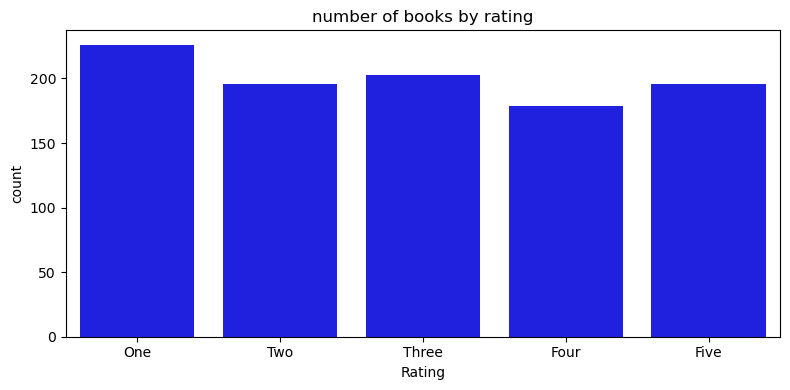

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns
rating=["One","Two","Three","Four","Five"]
counts=df['Rating'].value_counts().reindex(rating)
plt.figure(figsize=(8,4))
sns.barplot(x=counts.index,y=counts.values,color="blue")
plt.title("number of books by rating")
plt.xlabel("Rating")
plt.ylabel("count")
plt.tight_layout()
plt.show()

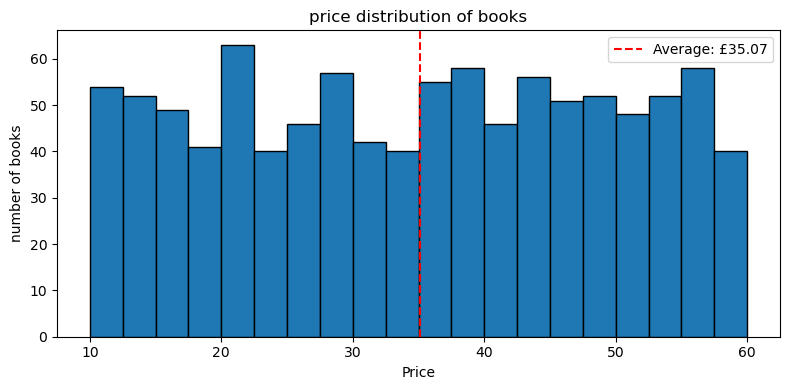

In [122]:
plt.figure(figsize=(8,4))
plt.hist(df["Price"], bins =20,edgecolor="black")
plt.title("price distribution of books")
plt.axvline(df["Price"].mean(), color="red", linestyle="--", label=f'Average: £{df["Price"].mean():.2f}')
plt.xlabel("Price")
plt.ylabel("number of books")
plt.tight_layout()
plt.legend()
plt.show()

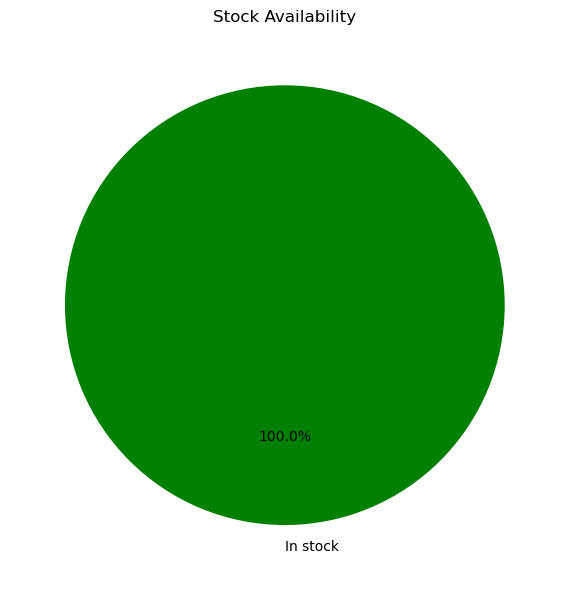

Stock
In stock    1000
Name: count, dtype: int64


In [123]:
# stock availability pie chart
stock_counts=df["Stock"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(stock_counts.values, labels=stock_counts.index,autopct="%1.1f%%",colors=["Green","red"],startangle=90)
plt.title("Stock Availability")
plt.tight_layout()
plt.show()
print(stock_counts)

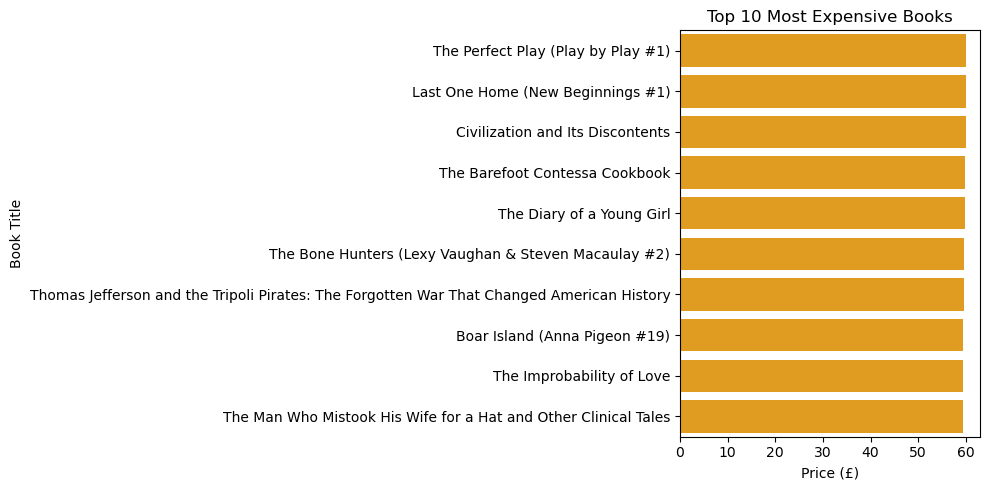

                                                                               Book Title  Price
                                                       The Perfect Play (Play by Play #1)  59.99
                                                        Last One Home (New Beginnings #1)  59.98
                                                         Civilization and Its Discontents  59.95
                                                           The Barefoot Contessa Cookbook  59.92
                                                                The Diary of a Young Girl  59.90
                                     The Bone Hunters (Lexy Vaughan & Steven Macaulay #2)  59.71
Thomas Jefferson and the Tripoli Pirates: The Forgotten War That Changed American History  59.64
                                                            Boar Island (Anna Pigeon #19)  59.48
                                                                The Improbability of Love  59.45
                          The 

In [124]:
top10=df.nlargest(10,"Price")[["Book Title","Price"]]
plt.figure(figsize=(10,5))
sns.barplot(x="Price",y="Book Title",data=top10,color="Orange")
plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price (£)")
plt.tight_layout()
plt.show()
print(top10.to_string(index=False))

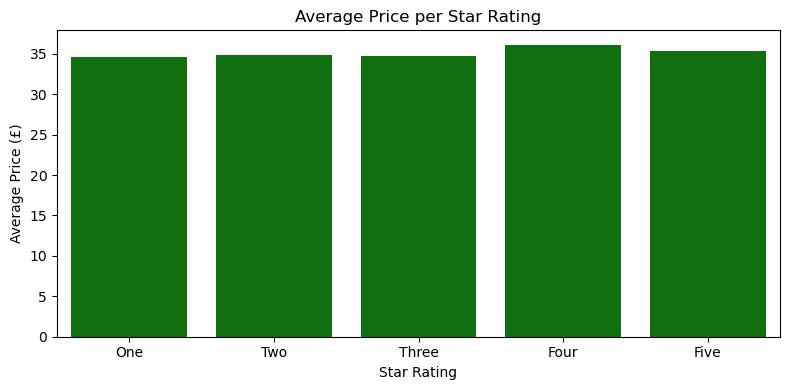

Rating
One      34.56
Two      34.81
Three    34.69
Four     36.09
Five     35.37
Name: Price, dtype: float64


In [103]:

rating_order = ["One","Two","Three","Four","Five"]
avg_price = df.groupby("Rating")["Price"].mean().reindex(rating_order)

plt.figure(figsize=(8,4))
sns.barplot(x=avg_price.index, y=avg_price.values, color="green")
plt.title("Average Price per Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average Price (£)")
plt.tight_layout()
plt.show()

print(avg_price.round(2))